<a href="https://colab.research.google.com/github/peperjet/deep-learning/blob/main/machine/mu6_4_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이 자료는 위키독스 딥 러닝을 이용한 자연어 처리 입문의 자동 미분과 선형 회귀 튜토리얼입니다.  

링크 : https://wikidocs.net/111472

# 1. 자동 미분

In [47]:
import tensorflow as tf

In [48]:
tf.__version__

'2.19.0'

In [49]:
w = tf.Variable(2.)

def f(w):
  y = w**2
  z = 2*y + 5
  return z

In [50]:
with tf.GradientTape() as tape:
  z = f(w)

gradients = tape.gradient(z, [w])
print(gradients)

[<tf.Tensor: shape=(), dtype=float32, numpy=8.0>]


예제) 블로그 방문자 수 예측하기

In [53]:
# x : 포스팅 개수
# y : 일일 방문자 수 (예시)

x = [1, 2, 3, 4, 5]
y = [150, 280, 420, 550, 710]

w = tf.Variable(0.0) # 초기 가중치
b = tf.Variable(0.0) # 초기 편향

# 최적화
optimizer = tf.optimizers.SGD(learning_rate=0.01)

for i in range(501):
  with tf.GradientTape() as tape:
    hypothesis = w*x + b
    cost = tf.reduce_mean(tf.square(hypothesis - y))

    grads = tape.gradient(cost, [w, b])
    optimizer.apply_gradients(grads_and_vars=zip(grads, [w, b]))

    if i % 50 == 0:
      print(f" 반복: {i}, W: {w.numpy()}, b: {b.numpy()}, 손실함수: {cost.numpy()}")

# 응용 : 포스팅 10개 올렸을 때 예상 방문자 수는? 미래 확인하기
test_x = 10
predict = w * test_x + b # 'W'를 'w'로 수정
print(f"\n[예측] 포스팅 {test_x}개 시 예상 방문자 수: {predict.numpy().item():.0f}명") # .item() 추가


 반복: 0, W: 30.8799991607666, b: 8.4399995803833, 손실함수: 216780.0
 반복: 50, W: 131.74891662597656, b: 31.178186416625977, 손실함수: 179.5845184326172
 반복: 100, W: 132.87855529785156, b: 27.100353240966797, 손실함수: 143.50607299804688
 반복: 150, W: 133.83213806152344, b: 23.657691955566406, 손실함수: 117.7927017211914
 반복: 200, W: 134.6371307373047, b: 20.751314163208008, 손실함수: 99.46630096435547
 반복: 250, W: 135.31675720214844, b: 18.297685623168945, 손실함수: 86.40470886230469
 반복: 300, W: 135.8905029296875, b: 16.226259231567383, 손실함수: 77.09547424316406
 반복: 350, W: 136.37489318847656, b: 14.47750473022461, 손실함수: 70.46055603027344
 반복: 400, W: 136.7838134765625, b: 13.00114631652832, 손실함수: 65.73126983642578
 반복: 450, W: 137.12904357910156, b: 11.754769325256348, 손실함수: 62.36138916015625
 반복: 500, W: 137.42047119140625, b: 10.702557563781738, 손실함수: 59.959327697753906

[예측] 포스팅 10개 시 예상 방문자 수: 1385명


# 2. 자동 미분을 이용한 선형 회귀 구현

In [54]:
# 학습될 가중치 변수를 선언
W = tf.Variable(4.0)
b = tf.Variable(1.0)

In [55]:
@tf.function
def hypothesis(x):
  return W*x + b

In [56]:
x_test = [3.5, 5, 5.5, 6]
print(hypothesis(x_test).numpy())

[15. 21. 23. 25.]


In [57]:
@tf.function
def mse_loss(y_pred, y):
  # 두 개의 차이값을 제곱을 해서 평균을 취한다.
  return tf.reduce_mean(tf.square(y_pred - y))

In [58]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9] # 공부하는 시간
y = [11, 22, 33, 44, 53, 66, 77, 87, 95] # 각 공부하는 시간에 맵핑되는 성적

In [59]:
optimizer = tf.optimizers.SGD(0.01)

In [60]:
for i in range(301):
  with tf.GradientTape() as tape:
    # 현재 파라미터에 기반한 입력 x에 대한 예측값을 y_pred
    y_pred = hypothesis(x)

    # 평균 제곱 오차를 계산
    cost = mse_loss(y_pred, y)

  # 손실 함수에 대한 파라미터의 미분값 계산
  gradients = tape.gradient(cost, [W, b])

  # 파라미터 업데이트
  optimizer.apply_gradients(zip(gradients, [W, b]))

  if i % 10 == 0:
    print("epoch : {:3} | W의 값 : {:5.4f} | b의 값 : {:5.4} | cost : {:5.6f}".format(i, W.numpy(), b.numpy(), cost))

epoch :   0 | W의 값 : 8.2133 | b의 값 : 1.664 | cost : 1402.555542
epoch :  10 | W의 값 : 10.4971 | b의 값 : 1.977 | cost : 1.351182
epoch :  20 | W의 값 : 10.5047 | b의 값 :  1.93 | cost : 1.328165
epoch :  30 | W의 값 : 10.5119 | b의 값 : 1.884 | cost : 1.306967
epoch :  40 | W의 값 : 10.5188 | b의 값 : 1.841 | cost : 1.287436
epoch :  50 | W의 값 : 10.5254 | b의 값 : 1.799 | cost : 1.269459
epoch :  60 | W의 값 : 10.5318 | b의 값 : 1.759 | cost : 1.252898
epoch :  70 | W의 값 : 10.5379 | b의 값 : 1.721 | cost : 1.237644
epoch :  80 | W의 값 : 10.5438 | b의 값 : 1.684 | cost : 1.223598
epoch :  90 | W의 값 : 10.5494 | b의 값 : 1.648 | cost : 1.210658
epoch : 100 | W의 값 : 10.5548 | b의 값 : 1.614 | cost : 1.198740
epoch : 110 | W의 값 : 10.5600 | b의 값 : 1.582 | cost : 1.187767
epoch : 120 | W의 값 : 10.5650 | b의 값 :  1.55 | cost : 1.177665
epoch : 130 | W의 값 : 10.5697 | b의 값 :  1.52 | cost : 1.168354
epoch : 140 | W의 값 : 10.5743 | b의 값 : 1.492 | cost : 1.159782
epoch : 150 | W의 값 : 10.5787 | b의 값 : 1.464 | cost : 1.151890
epoch 

In [61]:
x_test = [3.5, 5, 5.5, 6]
print(hypothesis(x_test).numpy())

[38.35479  54.295143 59.608593 64.92204 ]


학습과정 눈으로 확인하기 (Matplotlib)

--- 학습 시작 ---
step: 50, Loss: 0.0554, W: 1.880, b :0.524
step: 100, Loss: 0.0420, W: 1.902, b :0.446
step: 150, Loss: 0.0325, W: 1.920, b :0.379
step: 200, Loss: 0.0257, W: 1.936, b :0.323
step: 250, Loss: 0.0208, W: 1.949, b :0.276
step: 300, Loss: 0.0174, W: 1.960, b :0.236


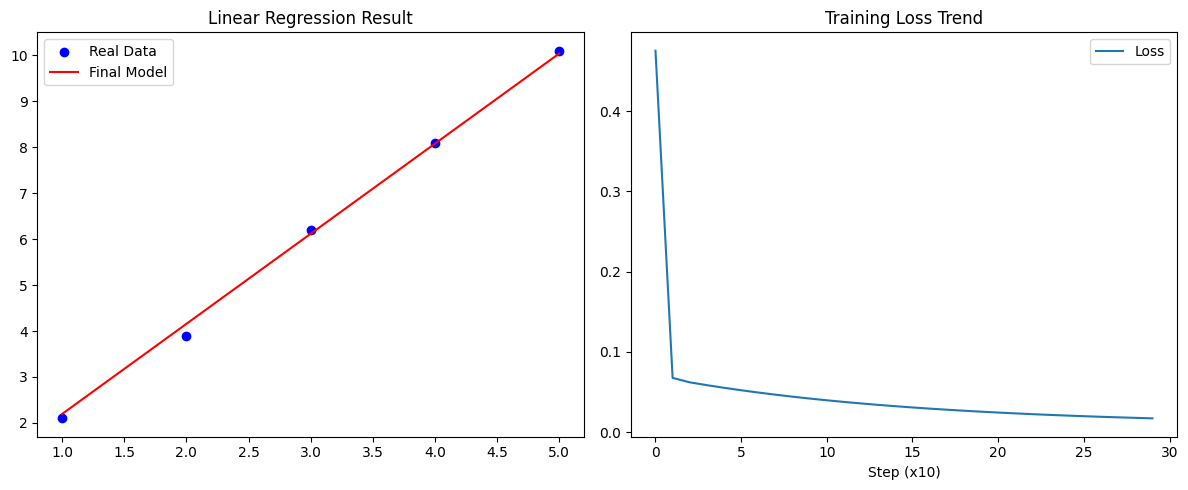

In [62]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


# 1. 데이터 셋 구성 (실제 값에 노이드 섞기)
x_data = np.array([1, 2, 3, 4, 5], dtype=np.float32)
y_data = np.array([2.1, 3.9, 6.2, 8.1, 10.1], dtype=np.float32) # 살짝 오차


# 2. 피라미터 초기화 (랜덤값으로 시작)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')


# 학습 과정기록
loss_history = []


# 3. 최적화 도구 설정
optimizer = tf.optimizers.SGD(learning_rate = 0.01)

print("--- 학습 시작 ---")


for i in range(1, 301):
  with tf.GradientTape() as tape:
      # 가설 및 손실 함수
      hypothesis = W * x_data + b
      cost = tf.reduce_mean(tf.square(hypothesis - y_data))

  # 오차 역전파 및 업데이트
  gradients = tape.gradient(cost, [W, b])
  optimizer.apply_gradients(zip(gradients, [W, b]))


  # 10번마다 손실값 기록 (공부 흔적)
  if i % 10 == 0:
    loss_history.append(cost.numpy())

  if i % 50 == 0:
    print(f"step: {i}, Loss: {cost.numpy():.4f}, W: {W.numpy()[0]:.3f}, b :{b.numpy()[0]:.3f}")

# 4. 결과 시각화 (두 개의 그래프를 그려서 분석한 척하기)
plt.figure(figsize=(12, 5))

# 그래프 1: 데이터와 회귀선
plt.subplot(1, 2, 1)
plt.scatter(x_data, y_data, color='blue', label='Real Data')
plt.plot(x_data, W.numpy() * x_data + b.numpy(), color='red', label='Final Model')
plt.title("Linear Regression Result")
plt.legend()

# 그래프 2: 손실(Loss) 감소 추이 (이게 있어야 열심히 한 느낌이 납니다)
plt.subplot(1, 2, 2)
plt.plot(loss_history, label='Loss')
plt.title("Training Loss Trend")
plt.xlabel("Step (x10)")
plt.legend()

plt.tight_layout()
plt.show()

- 데이터 노이즈 : 딱 떨어지는 [2, 4, 6...] 대신 [2.1, 3.9...] 처럼 실제 발생할 법한 데이터 사용
- Loss History : 손실 곡선(Loss Curve)을 그려 검증하는 과정 추가
- 로그 출력 : 50회마다 현재 진행 출력하도록 하여 학습 과정 모니터링
- sunplot 활용 : 그래프를 한 장에 몰아넣지 않고
결과와 과정을 시각화

# 3. 케라스로 구현하는 선형 회귀

In [69]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import optimizers

x = [1, 2, 3, 4, 5, 6, 7, 8, 9] # 공부하는 시간
y = [11, 22, 33, 44, 53, 66, 77, 87, 95] # 각 공부하는 시간에 맵핑되는 성적

model = Sequential()

# 입력 x의 차원은 1, 출력 y의 차원도 1. 선형 회귀이므로 activation은 'linear'
# Keras 권장사항에 따라 Input 레이어를 명시적으로 추가합니다.
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))

# sgd는 경사 하강법을 의미. 학습률(learning rate, lr)은 0.01.
sgd = optimizers.SGD(learning_rate=0.01)

# 손실 함수(Loss function)은 평균제곱오차 mse를 사용합니다.
model.compile(optimizer=sgd, loss='mse', metrics=['mse'])

# 주어진 x와 y데이터에 대해서 오차를 최소화하는 작업을 300번 시도합니다.
model.fit(np.array(x), np.array(y), epochs=300)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 3308.5405 - mse: 3308.5405
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 408.1314 - mse: 408.1314
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 51.2570 - mse: 51.2570
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7.3454 - mse: 7.3454
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.9415 - mse: 1.9415
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.2757 - mse: 1.2757
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.1929 - mse: 1.1929
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.1818 - mse: 1.1818
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.1796 - mse: 1.1796
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.1785 - mse: 1.1785
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.1775 - mse: 1.1775
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.1765 - mse: 1.1765
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


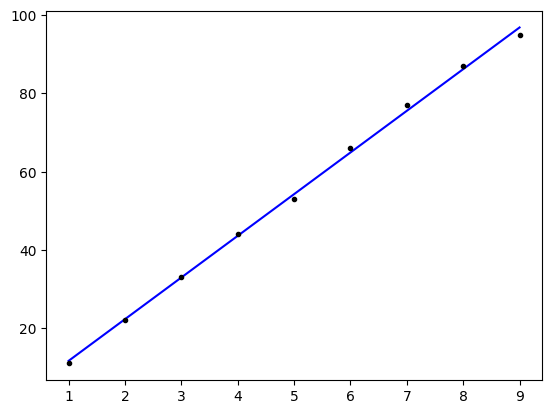

In [72]:
plt.plot(x, model.predict(np.array(x)), 'b', x, y, 'k.')

케라스(Keras) 스타일로 리팩토링(Sequential)

In [78]:
from tensorflow.keras import layers, models
import numpy as np

# 데이터 준비 (리스트 - 넘파이 배열로 변환)
# "kearas 모델 입력을 위해 데이터를 numpy array로"
x_train = np.array([1, 2, 3, 4, 5], dtype=np.float32)
y_train = np.array([2, 4, 6, 8, 10], dtype=np.float32)


# 모델 구성 (입력 1개, 출력1개인 단순 선형 회귀)
model = models.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])


# 모델 컵파일 (설계도 완성)
model.compile(optimizer='sgd', loss='mean_squared_error')

# 학습 (Verbose=0으로 설정하면 과정 출력 생략해 깔끔)
history = model.fit(x_train,y_train, epochs=500, verbose=0)


# 확인
print("학습 완료!")
print("x가 10일 때 예측값:", model.predict(np.array([10.0])))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


학습 완료!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
x가 10일 때 예측값: [[19.92606]]
